# CNN baseline

Первый baseline на PNG-рендерах с предобученной ResNet18.

## 1. Загрузка данных

Подключаем библиотеки, задаём пути и загружаем исходную таблицу с разметкой.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path('.')
TRAIN_CSV = ROOT / 'train(1).csv'
TRAIN_DIR = ROOT / 'train (2)' / 'train'

train = pd.read_csv(TRAIN_CSV)

print('Размер train:', train.shape)
train.head()

Размер train: (8964, 12)


,item_id,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
0,0001be62-bf9c-4c15-8a09-dce209be9715,0,1,0,0,0,0,0,0,0,0,0
1,000ad3b9-75cf-4b8f-9786-de63f9a8ffa8,0,0,0,0,0,0,0,0,0,1,0
2,0012e069-5caf-44fd-85e4-9a38f6eefd2e,0,0,0,0,0,0,0,0,0,1,0
3,0024dc8f-a2d7-4556-94dc-6b4b0f46ca0d,1,0,0,1,0,0,0,0,0,0,0
4,002b097b-4237-4610-952c-6095d48fb7a0,0,0,0,0,0,0,0,0,0,1,0


## 2. Целевые столбцы

Берём названия target напрямую из таблицы, исключая только `item_id`.

In [2]:
target_columns = [column for column in train.columns if column != 'item_id']

print('Количество target:', len(target_columns))
print(target_columns)

Количество target: 11
['abstract', 'artifacts', 'intersection', 'lowpoly', 'noisy', 'open', 'partial', 'scale', 'set', 'simple', 'quality']


## 3. Связь UUID с PNG

Для каждого `item_id` создаём путь к PNG и проверяем, что все изображения существуют.

In [3]:
train['image_path'] = train['item_id'].apply(
    lambda item_id: TRAIN_DIR / f'{item_id}.png'
)

missing_images = (~train['image_path'].apply(Path.exists)).sum()

print('PNG в папке:', len(list(TRAIN_DIR.glob('*.png'))))
print('Строк в таблице:', len(train))
print('Отсутствующих PNG:', missing_images)

PNG в папке: 8964
Строк в таблице: 8964
Отсутствующих PNG: 0


## 4. Пример изображения

Открываем один PNG и проверяем его размер и соответствующие target.

item_id: 0001be62-bf9c-4c15-8a09-dce209be9715
Размер изображения: (1536, 1024)
Target:


,Значение
abstract,0
artifacts,1
intersection,0
lowpoly,0
noisy,0
open,0
partial,0
scale,0
set,0
simple,0


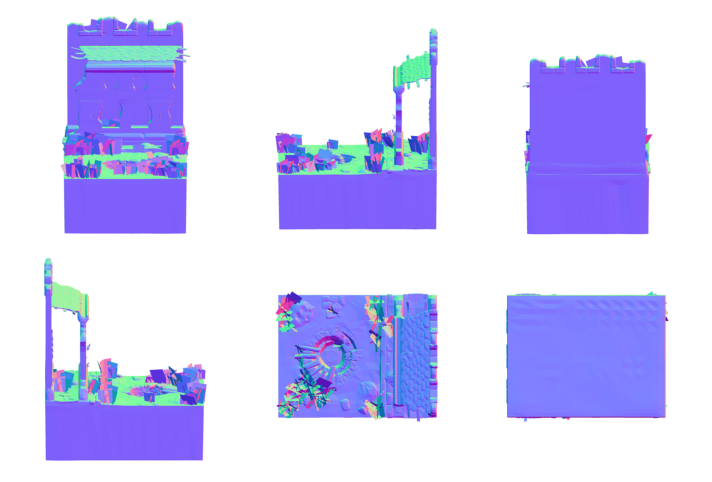

In [4]:
sample = train.iloc[0]
image = Image.open(sample['image_path']).convert('RGB')

print('item_id:', sample['item_id'])
print('Размер изображения:', image.size)
print('Target:')
display(sample[target_columns].to_frame('Значение'))

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis('off')
plt.show()

## 5. Train/validation/test split

Делим размеченные данные на train, validation и внутренний test. Официальный test в разработке модели не используем.

Сначала отделяем 15% данных для финальной проверки. Затем выделяем validation из оставшихся объектов.

In [5]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

test_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

train_val_index, test_index = next(
    test_splitter.split(train, train[target_columns])
)

train_val_df = train.iloc[train_val_index].reset_index(drop=True)
test_df = train.iloc[test_index].reset_index(drop=True)

val_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.1765,
    random_state=43
)

train_index, val_index = next(
    val_splitter.split(train_val_df, train_val_df[target_columns])
)

train_df = train_val_df.iloc[train_index].reset_index(drop=True)
val_df = train_val_df.iloc[val_index].reset_index(drop=True)

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Internal test:', test_df.shape)

all_split_ids = (
    set(train_df['item_id']) |
    set(val_df['item_id']) |
    set(test_df['item_id'])
)

print('Всего уникальных item_id:', len(all_split_ids))
print('Пересечение train/validation:', len(set(train_df['item_id']) & set(val_df['item_id'])))
print('Пересечение train/test:', len(set(train_df['item_id']) & set(test_df['item_id'])))
print('Пересечение validation/test:', len(set(val_df['item_id']) & set(test_df['item_id'])))

Train: (6259, 13)
Validation: (1361, 13)
Internal test: (1344, 13)
Всего уникальных item_id: 8964
Пересечение train/validation: 0
Пересечение train/test: 0
Пересечение validation/test: 0


Проверяем долю положительных примеров во всех трёх частях.

In [6]:
label_distribution = pd.DataFrame({
    'Все данные': train[target_columns].mean(),
    'Train': train_df[target_columns].mean(),
    'Validation': val_df[target_columns].mean(),
    'Internal test': test_df[target_columns].mean()
})

(label_distribution * 100).round(2)

,Все данные,Train,Validation,Internal test
abstract,13.32,13.36,13.15,13.32
artifacts,4.85,4.87,4.78,4.84
intersection,1.19,1.20,1.18,1.19
lowpoly,12.35,12.38,12.20,12.35
noisy,28.44,28.52,28.07,28.42
open,6.07,6.07,6.02,6.10
partial,4.19,4.22,4.11,4.17
scale,1.19,1.20,1.18,1.19
set,10.44,10.46,10.36,10.42
simple,21.52,21.58,21.23,21.50


## 6. Dataset и transforms

Преобразуем PNG в тензор, сохраняя пропорции исходного изображения, и применяем нормализацию ImageNet.

In [7]:
import random

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [8]:
image_transform = transforms.Compose([
    transforms.Resize((224, 336)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
class MeshRenderDataset(Dataset):
    def __init__(self, dataframe, target_columns, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.target_columns = target_columns
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(
            row[self.target_columns].to_numpy(dtype=np.float32),
            dtype=torch.float32
        )

        return image, target

## 7. DataLoader

Создаём загрузчики для обучения и validation.

In [10]:
BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataset = MeshRenderDataset(
    train_df,
    target_columns,
    transform=image_transform
)

val_dataset = MeshRenderDataset(
    val_df,
    target_columns,
    transform=image_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

images, targets = next(iter(train_loader))

print('Train объектов:', len(train_dataset))
print('Validation объектов:', len(val_dataset))
print('Размер batch изображений:', images.shape)
print('Размер batch target:', targets.shape)

Train объектов: 6259
Validation объектов: 1361
Размер batch изображений: torch.Size([32, 3, 224, 336])
Размер batch target: torch.Size([32, 11])


## 8. ResNet18

Загружаем предобученную ResNet18 и заменяем последний слой на 11 выходов.

In [11]:
import torch.nn as nn
from torchvision.models import ResNet18_Weights, resnet18

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, len(target_columns))
model = model.to(device)

print('Количество выходов:', model.fc.out_features)

Количество выходов: 11


## 9. Loss и optimizer

Используем `BCEWithLogitsLoss`. `pos_weight` повышает вес редких положительных меток.

In [12]:
positive_count = train_df[target_columns].sum().to_numpy()
negative_count = len(train_df) - positive_count
pos_weight = torch.tensor(
    negative_count / positive_count,
    dtype=torch.float32,
    device=device
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

pd.DataFrame({
    'target': target_columns,
    'pos_weight': pos_weight.cpu().numpy().round(2)
})

,target,pos_weight
0,abstract,6.490000
1,artifacts,19.520000
2,intersection,82.449997
3,lowpoly,7.080000
4,noisy,2.510000
5,open,15.470000
6,partial,22.709999
7,scale,82.449997
8,set,8.560000
9,simple,3.630000


## 10. Функции обучения и validation

На train обновляем веса, а на validation считаем loss и вероятности через sigmoid.

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_targets = []
    all_probabilities = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            loss = criterion(logits, targets)
            probabilities = torch.sigmoid(logits)

            total_loss += loss.item() * images.size(0)
            all_targets.append(targets.cpu().numpy())
            all_probabilities.append(probabilities.cpu().numpy())

    validation_loss = total_loss / len(loader.dataset)
    all_targets = np.concatenate(all_targets)
    all_probabilities = np.concatenate(all_probabilities)

    return validation_loss, all_targets, all_probabilities

## 11. Метрики

Используем threshold 0.5, считаем F1 каждого target и общую baseline-метрику.

In [14]:
from sklearn.metrics import f1_score

THRESHOLD = 0.5


def calculate_metrics(targets, probabilities, target_columns, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    f1_per_target = f1_score(
        targets,
        predictions,
        average=None,
        zero_division=0
    )

    metrics_table = pd.DataFrame({
        'target': target_columns,
        'F1': f1_per_target
    })

    defect_indices = [
        index for index, name in enumerate(target_columns)
        if name != 'quality'
    ]
    quality_index = target_columns.index('quality')

    defects_weighted_f1 = f1_score(
        targets[:, defect_indices],
        predictions[:, defect_indices],
        average='weighted',
        zero_division=0
    )
    quality_f1 = f1_per_target[quality_index]
    macro_f1 = f1_score(
        targets,
        predictions,
        average='macro',
        zero_division=0
    )
    competition_score = (quality_f1 + defects_weighted_f1) / 2

    summary = {
        'macro_f1': macro_f1,
        'defects_weighted_f1': defects_weighted_f1,
        'quality_f1': quality_f1,
        'competition_score': competition_score
    }

    return metrics_table, summary

## 12. Обучение

После каждой эпохи выводим train loss, validation loss и F1. Лучшую модель сохраняем по общей метрике.

In [15]:
EPOCHS = 3
MODEL_PATH = ROOT / 'best_resnet18_baseline_3way.pth'

history = []
best_score = -1

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_targets, val_probabilities = validate(
        model, val_loader, criterion, device
    )

    metrics_table, summary = calculate_metrics(
        val_targets,
        val_probabilities,
        target_columns,
        threshold=THRESHOLD
    )

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        **summary
    })

    print(
        f'Epoch {epoch + 1}/{EPOCHS} | '
        f'train loss: {train_loss:.4f} | '
        f'val loss: {val_loss:.4f} | '
        f'macro F1: {summary["macro_f1"]:.4f} | '
        f'score: {summary["competition_score"]:.4f}'
    )

    if summary['competition_score'] > best_score:
        best_score = summary['competition_score']

        torch.save({
            'model_state_dict': model.state_dict(),
            'target_columns': target_columns,
            'threshold': THRESHOLD,
            'validation_score': float(best_score)
        }, MODEL_PATH)

        print('Сохранена лучшая модель:', MODEL_PATH)

history = pd.DataFrame(history)
history

Epoch 1/3 | train loss: 0.9381 | val loss: 0.8889 | macro F1: 0.3825 | score: 0.4946
Сохранена лучшая модель: best_resnet18_baseline_3way.pth
Epoch 2/3 | train loss: 0.7004 | val loss: 0.7967 | macro F1: 0.4086 | score: 0.5312
Сохранена лучшая модель: best_resnet18_baseline_3way.pth
Epoch 3/3 | train loss: 0.5392 | val loss: 0.9164 | macro F1: 0.4337 | score: 0.5539
Сохранена лучшая модель: best_resnet18_baseline_3way.pth


,epoch,train_loss,val_loss,macro_f1,defects_weighted_f1,quality_f1,competition_score
0,1,0.938071,0.888915,0.382480,0.548238,0.440895,0.494566
1,2,0.700414,0.796709,0.408613,0.568526,0.493939,0.531233
2,3,0.539162,0.916422,0.433710,0.585364,0.522463,0.553913


## 13. Результаты лучшей модели

Загружаем лучший checkpoint и выводим F1 по каждому target и общие метрики.

In [16]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)
model.load_state_dict(checkpoint['model_state_dict'])

val_loss, val_targets, val_probabilities = validate(
    model, val_loader, criterion, device
)

metrics_table, summary = calculate_metrics(
    val_targets,
    val_probabilities,
    target_columns,
    threshold=THRESHOLD
)

display(metrics_table.round(4))

print('Validation loss:', round(val_loss, 4))
print('Macro F1:', round(summary['macro_f1'], 4))
print('Weighted F1 дефектов:', round(summary['defects_weighted_f1'], 4))
print('F1 quality:', round(summary['quality_f1'], 4))
print('Общая метрика:', round(summary['competition_score'], 4))

,target,F1
0,abstract,0.7111
1,artifacts,0.2186
2,intersection,0.0385
3,lowpoly,0.4150
4,noisy,0.7442
5,open,0.2429
6,partial,0.5176
7,scale,0.1702
8,set,0.5140
9,simple,0.6762


Validation loss: 0.9164
Macro F1: 0.4337
Weighted F1 дефектов: 0.5854
F1 quality: 0.5225
Общая метрика: 0.5539


## 14. Графики обучения

Показываем изменение loss и F1 по эпохам.

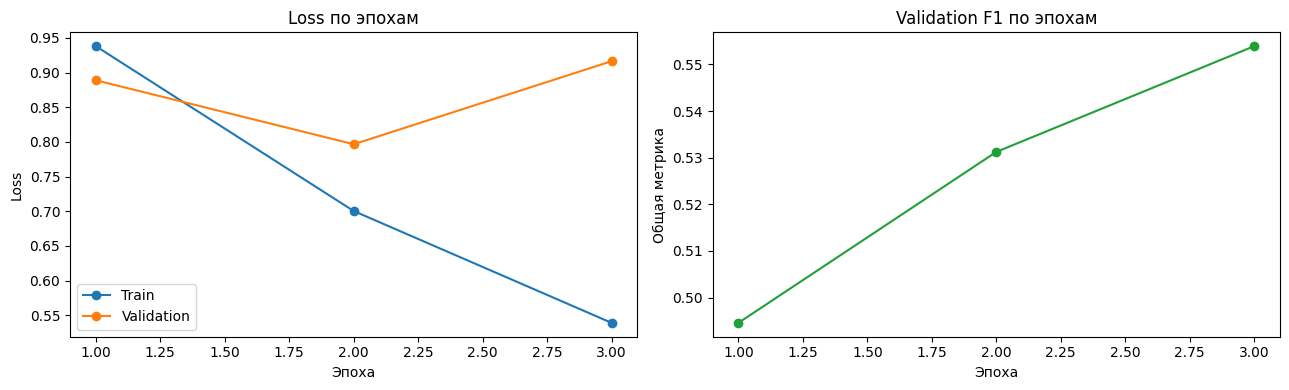

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='Train')
axes[0].plot(history['epoch'], history['val_loss'], marker='o', label='Validation')
axes[0].set_title('Loss по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(
    history['epoch'],
    history['competition_score'],
    marker='o',
    color='#21A038'
)
axes[1].set_title('Validation F1 по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Общая метрика')

plt.tight_layout()
plt.show()

# Анализ ошибок CNN

## 15. Метрики по классам

Считаем precision, recall, F1, количество объектов и положительных предсказаний для каждого target.

In [18]:
from sklearn.metrics import precision_recall_fscore_support

val_predictions = (val_probabilities >= THRESHOLD).astype(int)

precision, recall, f1, support = precision_recall_fscore_support(
    val_targets,
    val_predictions,
    average=None,
    zero_division=0
)

class_metrics = pd.DataFrame({
    'target': target_columns,
    'support': support,
    'predicted_positive': val_predictions.sum(axis=0),
    'precision': precision,
    'recall': recall,
    'F1': f1
}).sort_values('F1')

class_metrics.round(3)

,target,support,predicted_positive,precision,recall,F1
2,intersection,16,88,0.023,0.125,0.038
7,scale,16,78,0.103,0.500,0.170
1,artifacts,65,182,0.148,0.415,0.219
5,open,82,338,0.151,0.622,0.243
3,lowpoly,166,369,0.301,0.669,0.415
8,set,141,287,0.383,0.780,0.514
6,partial,56,114,0.386,0.786,0.518
10,quality,206,395,0.397,0.762,0.522
9,simple,289,409,0.577,0.817,0.676
0,abstract,179,226,0.637,0.804,0.711


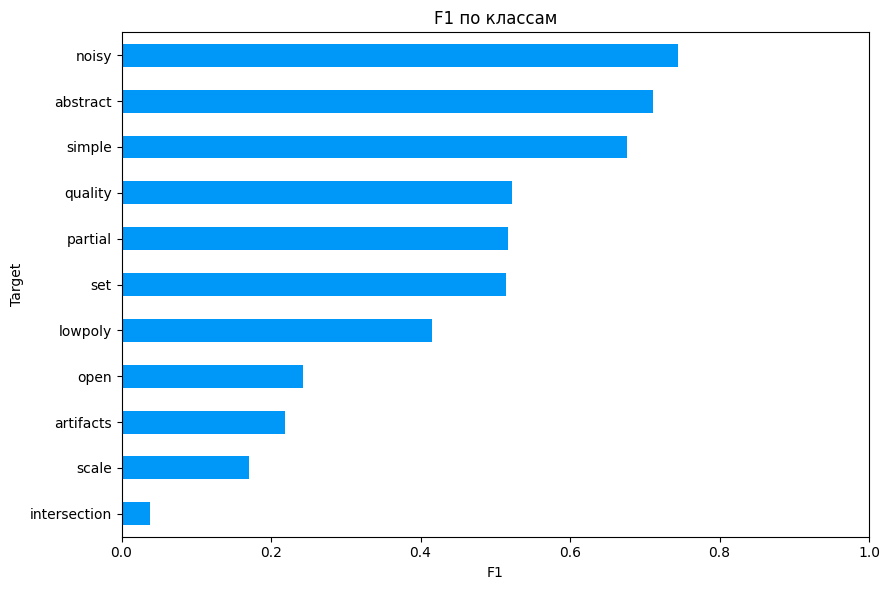

In [19]:
ax = class_metrics.plot.barh(
    x='target',
    y='F1',
    figsize=(9, 6),
    color='#0098F8',
    legend=False,
    title='F1 по классам'
)

ax.set_xlabel('F1')
ax.set_ylabel('Target')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 16. Типы ошибок

Для каждого target считаем true positive, false positive, false negative и true negative.

In [20]:
error_rows = []

for index, target_name in enumerate(target_columns):
    y_true = val_targets[:, index].astype(int)
    y_pred = val_predictions[:, index]

    error_rows.append({
        'target': target_name,
        'TP': int(((y_true == 1) & (y_pred == 1)).sum()),
        'FP': int(((y_true == 0) & (y_pred == 1)).sum()),
        'FN': int(((y_true == 1) & (y_pred == 0)).sum()),
        'TN': int(((y_true == 0) & (y_pred == 0)).sum())
    })

error_table = pd.DataFrame(error_rows)
error_table

,target,TP,FP,FN,TN
0,abstract,144,82,35,1100
1,artifacts,27,155,38,1141
2,intersection,2,86,14,1259
3,lowpoly,111,258,55,937
4,noisy,323,163,59,816
5,open,51,287,31,992
6,partial,44,70,12,1235
7,scale,8,70,8,1275
8,set,110,177,31,1043
9,simple,236,173,53,899


## 17. Самые сложные классы

Выводим классы с минимальным F1.

In [21]:
hardest_targets = class_metrics.head(5)['target'].tolist()

print('Самые сложные классы:')
for target_name in hardest_targets:
    print('-', target_name)

Самые сложные классы:
- intersection
- scale
- artifacts
- open
- lowpoly


## 18. Ошибки на изображениях

Показываем false positive и false negative для выбранного класса.

In [22]:
def show_errors(target_name, error_type='false_positive', count=4):
    target_index = target_columns.index(target_name)
    y_true = val_targets[:, target_index].astype(int)
    y_pred = val_predictions[:, target_index]

    if error_type == 'false_positive':
        error_indices = np.where((y_true == 0) & (y_pred == 1))[0]
        title = 'False positive'
    elif error_type == 'false_negative':
        error_indices = np.where((y_true == 1) & (y_pred == 0))[0]
        title = 'False negative'
    else:
        raise ValueError('Используйте false_positive или false_negative')

    error_indices = error_indices[:count]

    if len(error_indices) == 0:
        print('Ошибок этого типа нет')
        return

    fig, axes = plt.subplots(1, len(error_indices), figsize=(5 * len(error_indices), 4))
    axes = np.atleast_1d(axes)

    for ax, error_index in zip(axes, error_indices):
        row = val_df.iloc[error_index]
        probability = val_probabilities[error_index, target_index]
        image = Image.open(row['image_path']).convert('RGB')

        ax.imshow(image)
        ax.set_title(f'{title}\n{target_name}: {probability:.3f}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Класс: intersection


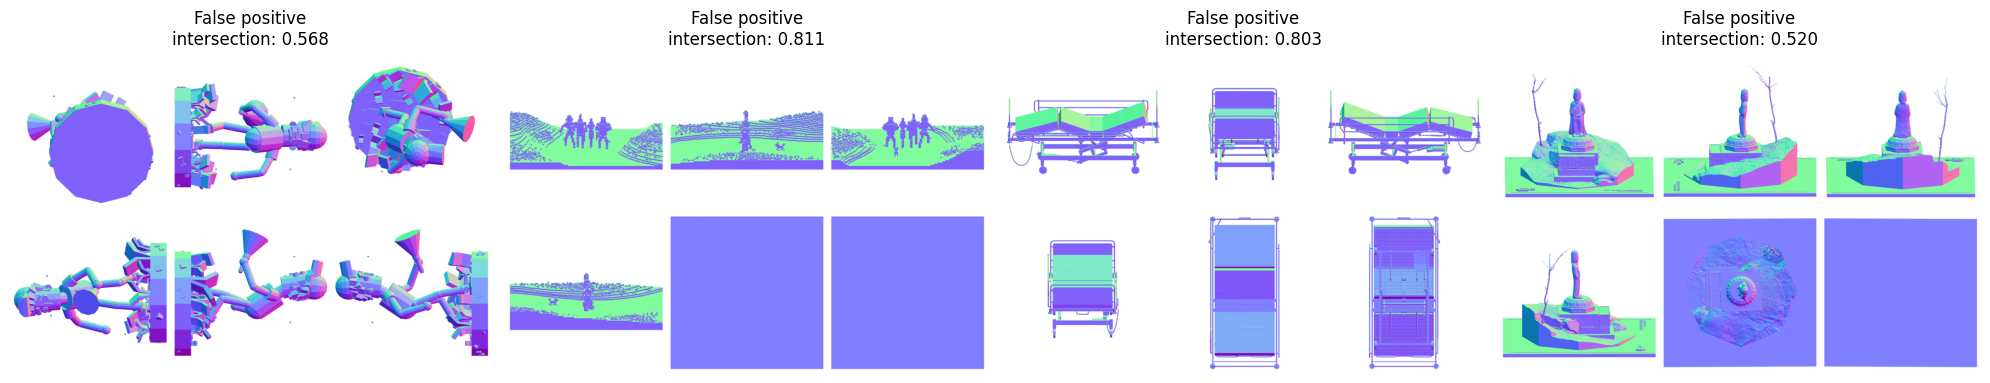

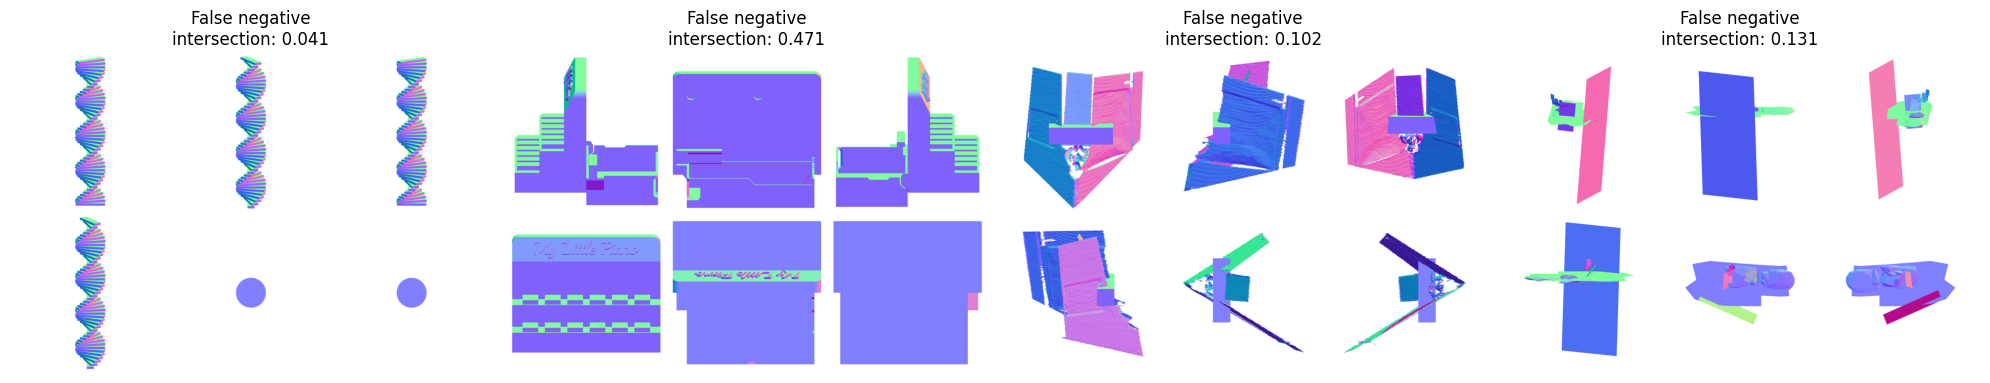

In [23]:
hardest_target = class_metrics.iloc[0]['target']

print('Класс:', hardest_target)
show_errors(hardest_target, 'false_positive')
show_errors(hardest_target, 'false_negative')

# Threshold tuning

## 19. Подбор порогов

Для каждого target отдельно перебираем пороги от 0.05 до 0.95 и выбираем значение с максимальным F1 на validation.

In [24]:
threshold_grid = np.arange(0.05, 0.96, 0.01)

best_thresholds = []
tuning_rows = []

for target_index, target_name in enumerate(target_columns):
    y_true = val_targets[:, target_index]
    probabilities = val_probabilities[:, target_index]

    f1_values = []

    for threshold in threshold_grid:
        predictions = (probabilities >= threshold).astype(int)
        f1 = f1_score(y_true, predictions, zero_division=0)
        f1_values.append(f1)

    best_index = int(np.argmax(f1_values))
    best_threshold = float(threshold_grid[best_index])
    best_f1 = float(f1_values[best_index])
    baseline_f1 = f1_score(
        y_true,
        (probabilities >= 0.5).astype(int),
        zero_division=0
    )

    best_thresholds.append(best_threshold)
    tuning_rows.append({
        'target': target_name,
        'threshold': best_threshold,
        'F1 при 0.5': baseline_f1,
        'F1 после tuning': best_f1,
        'изменение F1': best_f1 - baseline_f1
    })

best_thresholds = np.array(best_thresholds)
threshold_table = pd.DataFrame(tuning_rows)
threshold_table.round(3)

,target,threshold,F1 при 0.5,F1 после tuning,изменение F1
0,abstract,0.55,0.711,0.728,0.017
1,artifacts,0.49,0.219,0.235,0.017
2,intersection,0.71,0.038,0.103,0.064
3,lowpoly,0.61,0.415,0.422,0.007
4,noisy,0.62,0.744,0.754,0.010
5,open,0.78,0.243,0.301,0.058
6,partial,0.67,0.518,0.636,0.118
7,scale,0.92,0.170,0.385,0.214
8,set,0.71,0.514,0.560,0.046
9,simple,0.58,0.676,0.690,0.014


## 20. Сравнение метрик

Сравниваем общий результат при едином пороге `0.5` и при отдельных порогах классов.

In [25]:
tuned_metrics_table, tuned_summary = calculate_metrics(
    val_targets,
    val_probabilities,
    target_columns,
    threshold=best_thresholds
)

threshold_comparison = pd.DataFrame({
    'Вариант': ['Threshold 0.5', 'Отдельные thresholds'],
    'Macro F1': [summary['macro_f1'], tuned_summary['macro_f1']],
    'Weighted F1 дефектов': [
        summary['defects_weighted_f1'],
        tuned_summary['defects_weighted_f1']
    ],
    'F1 quality': [summary['quality_f1'], tuned_summary['quality_f1']],
    'Score': [
        summary['competition_score'],
        tuned_summary['competition_score']
    ]
})

display(threshold_comparison.round(4))
display(tuned_metrics_table.round(4))

,Вариант,Macro F1,Weighted F1 дефектов,F1 quality,Score
0,Threshold 0.5,0.4337,0.5854,0.5225,0.5539
1,Отдельные thresholds,0.4876,0.6105,0.5514,0.5810


,target,F1
0,abstract,0.7277
1,artifacts,0.2353
2,intersection,0.1026
3,lowpoly,0.4215
4,noisy,0.7538
5,open,0.3010
6,partial,0.6357
7,scale,0.3846
8,set,0.5595
9,simple,0.6901


## 21. Пороги по классам

Показываем выбранный threshold каждого target.

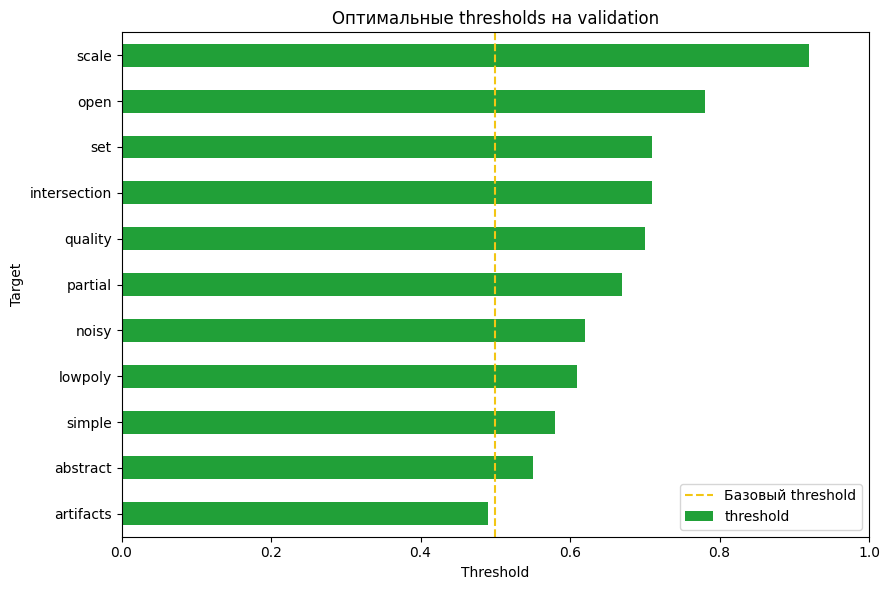

In [26]:
threshold_plot = threshold_table.sort_values('threshold')

ax = threshold_plot.plot.barh(
    x='target',
    y='threshold',
    figsize=(9, 6),
    color='#21A038',
    legend=False,
    title='Оптимальные thresholds на validation'
)

ax.axvline(0.5, color='#F2C614', linestyle='--', label='Базовый threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Target')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 22. Сохранение порогов

Сохраняем найденные значения для следующих этапов.

In [27]:
import json

thresholds_dict = {
    target_name: float(threshold)
    for target_name, threshold in zip(target_columns, best_thresholds)
}

THRESHOLDS_PATH = ROOT / 'resnet18_thresholds.json'

with open(THRESHOLDS_PATH, 'w', encoding='utf-8') as file:
    json.dump(thresholds_dict, file, indent=2, ensure_ascii=False)

print('Пороги сохранены:', THRESHOLDS_PATH)
thresholds_dict

Пороги сохранены: resnet18_thresholds.json


{'abstract': 0.5500000000000002,
 'artifacts': 0.49000000000000005,
 'intersection': 0.7100000000000002,
 'lowpoly': 0.6100000000000001,
 'noisy': 0.6200000000000001,
 'open': 0.7800000000000001,
 'partial': 0.6700000000000002,
 'scale': 0.9200000000000003,
 'set': 0.7100000000000002,
 'simple': 0.5800000000000002,
 'quality': 0.7000000000000002}

# Улучшение ResNet18

## 23. Аугментации

Добавляем лёгкие преобразования без обрезания отдельных ракурсов.

In [28]:
train_transform_augmented = transforms.Compose([
    transforms.Resize((224, 336)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = image_transform

## 24. Новые DataLoader

Аугментации применяются только к train. Validation остаётся без изменений.

In [29]:
augmented_train_dataset = MeshRenderDataset(
    train_df,
    target_columns,
    transform=train_transform_augmented
)

improved_val_dataset = MeshRenderDataset(
    val_df,
    target_columns,
    transform=val_transform
)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

improved_val_loader = DataLoader(
    improved_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print('Train объектов:', len(augmented_train_dataset))
print('Validation объектов:', len(improved_val_dataset))

Train объектов: 6259
Validation объектов: 1361


## 25. Частичный fine-tuning

Загружаем лучший baseline и обучаем только `layer4` и `fc`.

In [30]:
IMPROVED_MODEL_PATH = ROOT / 'best_resnet18_improved.pth'

baseline_checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

improved_model = resnet18(weights=None)
improved_model.fc = nn.Linear(
    improved_model.fc.in_features,
    len(target_columns)
)
improved_model.load_state_dict(baseline_checkpoint['model_state_dict'])

for parameter in improved_model.parameters():
    parameter.requires_grad = False

for parameter in improved_model.layer4.parameters():
    parameter.requires_grad = True

for parameter in improved_model.fc.parameters():
    parameter.requires_grad = True

improved_model = improved_model.to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in improved_model.parameters()
    if parameter.requires_grad
)

print('Обучаемых параметров:', f'{trainable_parameters:,}')

Обучаемых параметров: 8,399,371


## 26. Optimizer

Используем небольшой learning rate для последнего блока и классификатора.

In [31]:
improved_optimizer = torch.optim.AdamW([
    {'params': improved_model.layer4.parameters(), 'lr': 2e-5},
    {'params': improved_model.fc.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)

## 27. Обучение улучшенной модели

Обучаем три эпохи и сохраняем лучший validation checkpoint.

In [32]:
def train_one_epoch_finetune(model, loader, criterion, optimizer, device):
    model.train()

    model.conv1.eval()
    model.bn1.eval()
    model.layer1.eval()
    model.layer2.eval()
    model.layer3.eval()

    total_loss = 0

    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


IMPROVED_EPOCHS = 3
improved_history = []
best_improved_score = -1

for epoch in range(IMPROVED_EPOCHS):
    train_loss = train_one_epoch_finetune(
        improved_model,
        augmented_train_loader,
        criterion,
        improved_optimizer,
        device
    )

    val_loss, improved_val_targets, improved_val_probabilities = validate(
        improved_model,
        improved_val_loader,
        criterion,
        device
    )

    improved_metrics, improved_summary = calculate_metrics(
        improved_val_targets,
        improved_val_probabilities,
        target_columns,
        threshold=best_thresholds
    )

    improved_history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        **improved_summary
    })

    print(
        f'Epoch {epoch + 1}/{IMPROVED_EPOCHS} | '
        f'train loss: {train_loss:.4f} | '
        f'val loss: {val_loss:.4f} | '
        f'macro F1: {improved_summary["macro_f1"]:.4f} | '
        f'score: {improved_summary["competition_score"]:.4f}'
    )

    if improved_summary['competition_score'] > best_improved_score:
        best_improved_score = improved_summary['competition_score']

        torch.save({
            'model_state_dict': improved_model.state_dict(),
            'target_columns': target_columns,
            'thresholds': best_thresholds.tolist(),
            'validation_score': float(best_improved_score)
        }, IMPROVED_MODEL_PATH)

        print('Сохранена лучшая модель:', IMPROVED_MODEL_PATH)

improved_history = pd.DataFrame(improved_history)
improved_history

Epoch 1/3 | train loss: 0.4894 | val loss: 0.9592 | macro F1: 0.4881 | score: 0.5882
Сохранена лучшая модель: best_resnet18_improved.pth
Epoch 2/3 | train loss: 0.4331 | val loss: 1.0131 | macro F1: 0.4742 | score: 0.5849
Epoch 3/3 | train loss: 0.3963 | val loss: 1.1482 | macro F1: 0.4861 | score: 0.5816


,epoch,train_loss,val_loss,macro_f1,defects_weighted_f1,quality_f1,competition_score
0,1,0.489370,0.959206,0.488138,0.611167,0.565310,0.588239
1,2,0.433064,1.013098,0.474243,0.607192,0.562637,0.584914
2,3,0.396326,1.148206,0.486057,0.612825,0.550308,0.581566


## 28. Результаты улучшенной модели

Сравниваем baseline и улучшенную модель на одной validation.

In [33]:
improved_checkpoint = torch.load(
    IMPROVED_MODEL_PATH,
    map_location=device,
    weights_only=False
)
improved_model.load_state_dict(improved_checkpoint['model_state_dict'])

improved_val_loss, improved_val_targets, improved_val_probabilities = validate(
    improved_model,
    improved_val_loader,
    criterion,
    device
)

improved_metrics, improved_summary = calculate_metrics(
    improved_val_targets,
    improved_val_probabilities,
    target_columns,
    threshold=best_thresholds
)

model_comparison = pd.DataFrame({
    'Модель': ['ResNet18 baseline', 'ResNet18 improved'],
    'Macro F1': [tuned_summary['macro_f1'], improved_summary['macro_f1']],
    'Weighted F1 дефектов': [
        tuned_summary['defects_weighted_f1'],
        improved_summary['defects_weighted_f1']
    ],
    'F1 quality': [
        tuned_summary['quality_f1'],
        improved_summary['quality_f1']
    ],
    'Score': [
        tuned_summary['competition_score'],
        improved_summary['competition_score']
    ]
})

display(model_comparison.round(4))
display(improved_metrics.round(4))

,Модель,Macro F1,Weighted F1 дефектов,F1 quality,Score
0,ResNet18 baseline,0.4876,0.6105,0.5514,0.5810
1,ResNet18 improved,0.4881,0.6112,0.5653,0.5882


,target,F1
0,abstract,0.7366
1,artifacts,0.2941
2,intersection,0.0625
3,lowpoly,0.4213
4,noisy,0.7477
5,open,0.3311
6,partial,0.5594
7,scale,0.4000
8,set,0.5630
9,simple,0.6884


## 29. Графики fine-tuning

Показываем loss и validation score по эпохам.

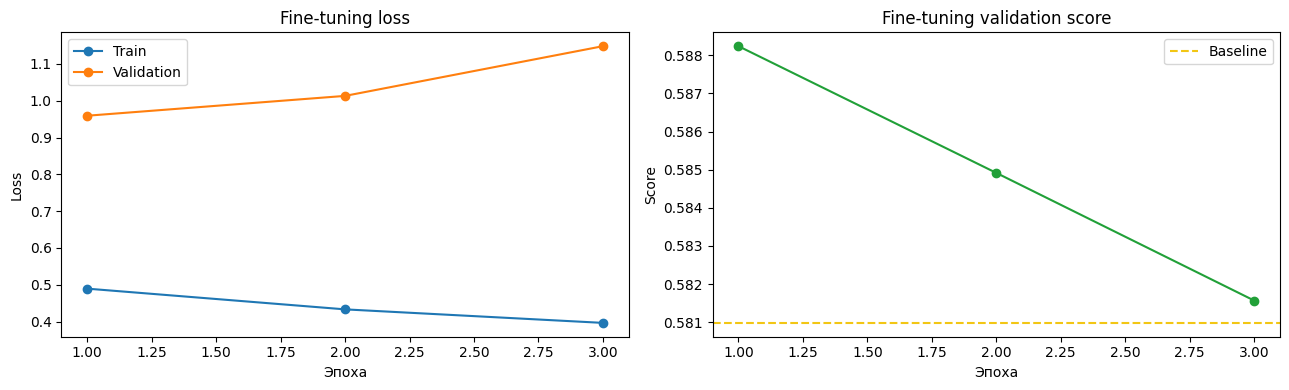

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(improved_history['epoch'], improved_history['train_loss'], marker='o', label='Train')
axes[0].plot(improved_history['epoch'], improved_history['val_loss'], marker='o', label='Validation')
axes[0].set_title('Fine-tuning loss')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(
    improved_history['epoch'],
    improved_history['competition_score'],
    marker='o',
    color='#21A038'
)
axes[1].axhline(
    tuned_summary['competition_score'],
    color='#F2C614',
    linestyle='--',
    label='Baseline'
)
axes[1].set_title('Fine-tuning validation score')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

# Threshold tuning улучшенной модели

## 30. Новые пороги

После fine-tuning заново подбираем отдельный threshold каждого класса на validation.

In [36]:
improved_thresholds = []
improved_tuning_rows = []

for target_index, target_name in enumerate(target_columns):
    y_true = improved_val_targets[:, target_index]
    probabilities = improved_val_probabilities[:, target_index]

    f1_values = []

    for threshold in threshold_grid:
        predictions = (probabilities >= threshold).astype(int)
        f1 = f1_score(y_true, predictions, zero_division=0)
        f1_values.append(f1)

    best_index = int(np.argmax(f1_values))
    best_threshold = float(threshold_grid[best_index])
    old_threshold = float(best_thresholds[target_index])
    old_f1 = f1_score(
        y_true,
        (probabilities >= old_threshold).astype(int),
        zero_division=0
    )

    improved_thresholds.append(best_threshold)
    improved_tuning_rows.append({
        'target': target_name,
        'старый threshold': old_threshold,
        'новый threshold': best_threshold,
        'F1 со старым': old_f1,
        'F1 с новым': float(f1_values[best_index]),
        'изменение F1': float(f1_values[best_index] - old_f1)
    })

improved_thresholds = np.array(improved_thresholds)
improved_threshold_table = pd.DataFrame(improved_tuning_rows)
improved_threshold_table.round(3)

,target,старый threshold,новый threshold,F1 со старым,F1 с новым,изменение F1
0,abstract,0.55,0.61,0.737,0.744,0.008
1,artifacts,0.49,0.52,0.294,0.320,0.026
2,intersection,0.71,0.70,0.062,0.118,0.055
3,lowpoly,0.61,0.66,0.421,0.435,0.014
4,noisy,0.62,0.51,0.748,0.749,0.001
5,open,0.78,0.79,0.331,0.333,0.002
6,partial,0.67,0.84,0.559,0.618,0.059
7,scale,0.92,0.90,0.400,0.429,0.029
8,set,0.71,0.71,0.563,0.563,0.000
9,simple,0.58,0.45,0.688,0.697,0.008


## 31. Итог ResNet18

Сравниваем baseline и улучшенную модель после повторного подбора порогов.

In [37]:
improved_tuned_metrics, improved_tuned_summary = calculate_metrics(
    improved_val_targets,
    improved_val_probabilities,
    target_columns,
    threshold=improved_thresholds
)

final_resnet_comparison = pd.DataFrame({
    'Вариант': [
        'Baseline + tuned thresholds',
        'Improved + старые thresholds',
        'Improved + новые thresholds'
    ],
    'Macro F1': [
        tuned_summary['macro_f1'],
        improved_summary['macro_f1'],
        improved_tuned_summary['macro_f1']
    ],
    'Weighted F1 дефектов': [
        tuned_summary['defects_weighted_f1'],
        improved_summary['defects_weighted_f1'],
        improved_tuned_summary['defects_weighted_f1']
    ],
    'F1 quality': [
        tuned_summary['quality_f1'],
        improved_summary['quality_f1'],
        improved_tuned_summary['quality_f1']
    ],
    'Score': [
        tuned_summary['competition_score'],
        improved_summary['competition_score'],
        improved_tuned_summary['competition_score']
    ]
})

display(final_resnet_comparison.round(4))
display(improved_tuned_metrics.round(4))

,Вариант,Macro F1,Weighted F1 дефектов,F1 quality,Score
0,Baseline + tuned thresholds,0.4876,0.6105,0.5514,0.5810
1,Improved + старые thresholds,0.4881,0.6112,0.5653,0.5882
2,Improved + новые thresholds,0.5069,0.6204,0.5708,0.5956


,target,F1
0,abstract,0.7443
1,artifacts,0.3196
2,intersection,0.1176
3,lowpoly,0.4350
4,noisy,0.7488
5,open,0.3333
6,partial,0.6182
7,scale,0.4286
8,set,0.5630
9,simple,0.6966


## 32. Сохранение новых порогов

Сохраняем thresholds улучшенной модели отдельно от baseline.

In [38]:
improved_thresholds_dict = {
    target_name: float(threshold)
    for target_name, threshold in zip(target_columns, improved_thresholds)
}

IMPROVED_THRESHOLDS_PATH = ROOT / 'resnet18_improved_thresholds.json'

with open(IMPROVED_THRESHOLDS_PATH, 'w', encoding='utf-8') as file:
    json.dump(
        improved_thresholds_dict,
        file,
        indent=2,
        ensure_ascii=False
    )

print('Пороги сохранены:', IMPROVED_THRESHOLDS_PATH)
improved_thresholds_dict

Пороги сохранены: resnet18_improved_thresholds.json


{'abstract': 0.6100000000000001,
 'artifacts': 0.5200000000000001,
 'intersection': 0.7000000000000002,
 'lowpoly': 0.6600000000000001,
 'noisy': 0.5100000000000001,
 'open': 0.7900000000000001,
 'partial': 0.8400000000000002,
 'scale': 0.9000000000000002,
 'set': 0.7100000000000002,
 'simple': 0.45000000000000007,
 'quality': 0.6800000000000002}